<span style='color:#c21da9'> practicing a imputer techqunics in real world </span>

In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [169]:
df = pd.read_csv("D:\\Data Sets☠️💀\\indian_food.csv")

In [170]:
df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [171]:
df.shape

(255, 9)

In [172]:
df.isna().sum()

name              0
ingredients       0
diet              0
prep_time         0
cook_time         0
flavor_profile    0
course            0
state             0
region            1
dtype: int64

In [173]:
def nan_values(s):
    for i in range(0,len(s),5):
        s.iloc[i] = np.nan
    return s # type: ignore

In [174]:
df[['diet','course','region','ingredients']]= nan_values(df[['diet','course','region','ingredients']])

C:\Users\91766\AppData\Local\Temp\ipykernel_21288\108850617.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s.iloc[i] = np.nan


In [175]:
df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,NaN,NaN,45,25,sweet,NaN,West Bengal,NaN
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [176]:
df['state'].value_counts()

state
Gujarat            35
Punjab             32
Maharashtra        30
-1                 24
West Bengal        24
Assam              21
Tamil Nadu         20
Andhra Pradesh     10
Uttar Pradesh       9
Kerala              8
Odisha              7
Karnataka           6
Rajasthan           6
Telangana           5
Bihar               3
Goa                 3
Madhya Pradesh      2
Jammu & Kashmir     2
Manipur             2
Uttarakhand         1
Tripura             1
NCT of Delhi        1
Nagaland            1
Haryana             1
Chhattisgarh        1
Name: count, dtype: int64

In [177]:
df['region'].value_counts()

region
West          61
South         46
North         40
East          24
North East    18
-1            12
Central        3
Name: count, dtype: int64

In [178]:
df.isna().mean() * 100

name               0.0
ingredients       20.0
diet              20.0
prep_time          0.0
cook_time          0.0
flavor_profile     0.0
course            20.0
state              0.0
region            20.0
dtype: float64

<Axes: ylabel='Density'>

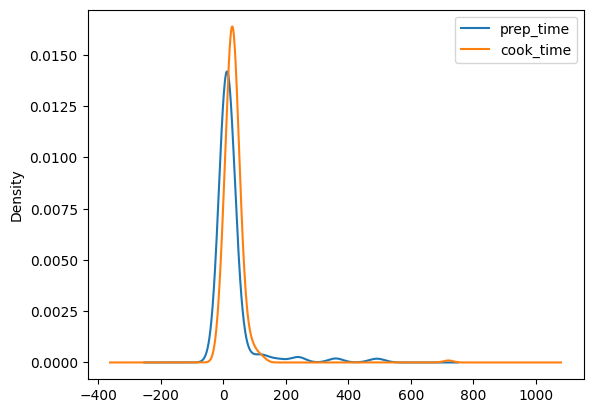

In [179]:
df.plot(kind='kde')

In [180]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

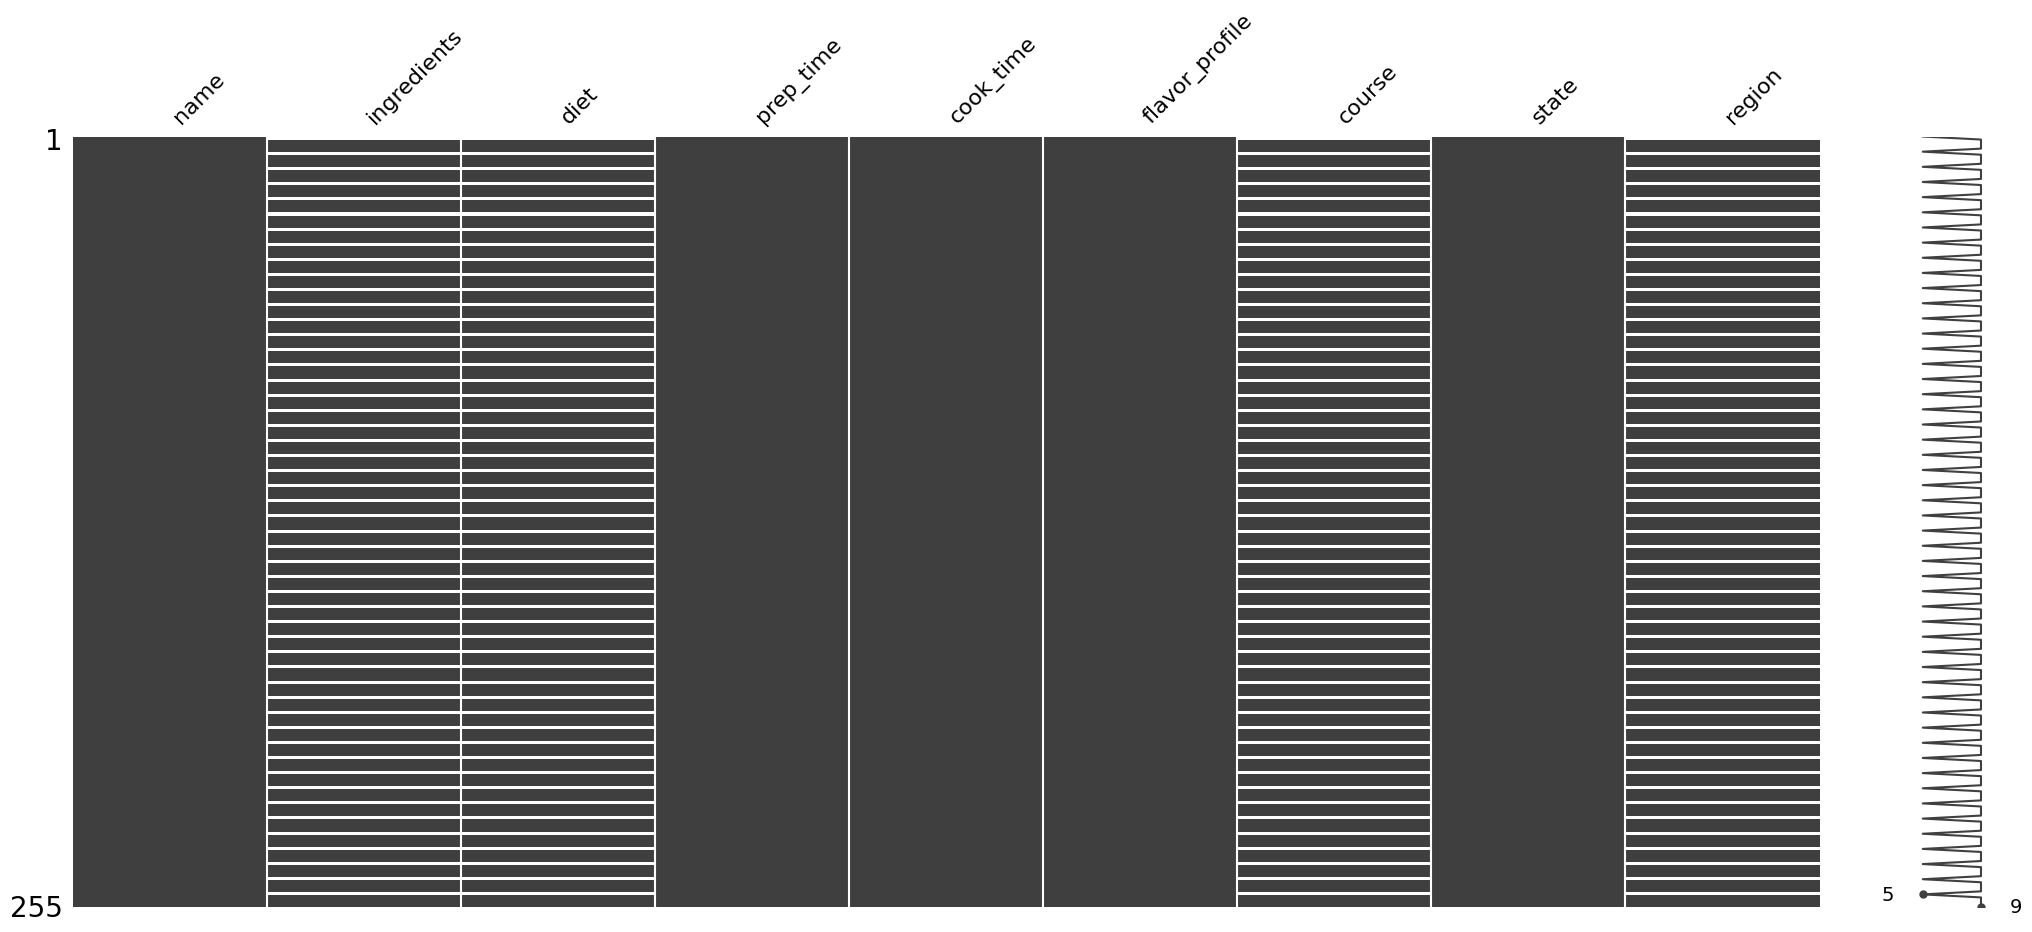

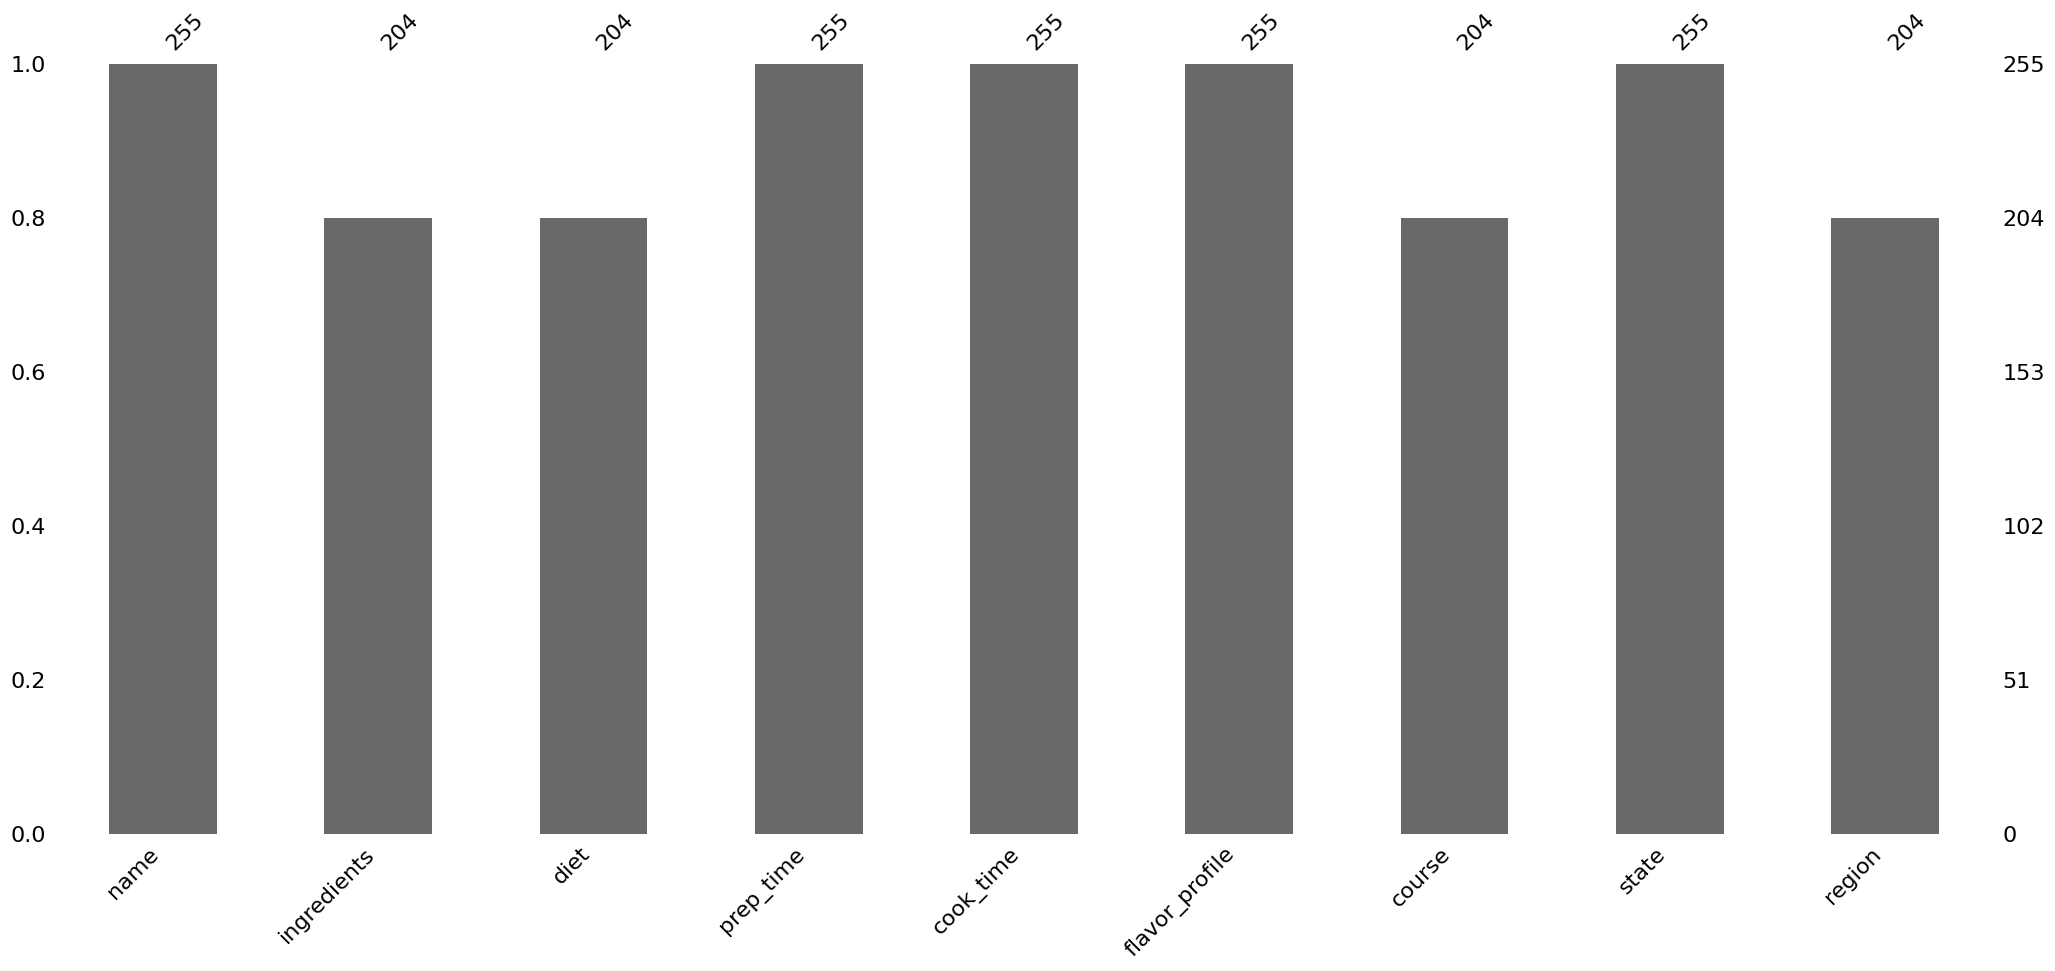

In [181]:
import missingno as msno # type: ignore

msno.matrix(df)
plt.show()


msno.bar(df)
plt.show()

In [182]:
impute = SimpleImputer()

In [183]:
df.columns

Index(['name', 'ingredients', 'diet', 'prep_time', 'cook_time',
       'flavor_profile', 'course', 'state', 'region'],
      dtype='object')

In [184]:
x = df.drop('state',axis=1)
y = df['state']

In [185]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [186]:
x_train

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,region
38,Bandar laddu,"Besan, jaggery, cardamom powder, ghee, cashews...",vegetarian,5,35,sweet,dessert,South
143,Kuzhambu,"Pearl onions, urad dal, drumsticks, tomato, cu...",vegetarian,5,30,spicy,main course,South
84,Daal puri,"Moong dal, garam masala powder, garlic, green ...",vegetarian,30,30,spicy,main course,East
55,Anarsa,NaN,NaN,10,50,sweet,NaN,NaN
219,Churma Ladoo,"Whole wheat flour, khus khus, sesame seeds, dr...",vegetarian,12,40,sweet,dessert,West
...,...,...,...,...,...,...,...,...
106,Palak paneer,"Cottage cheese, palak, cream, garam masala, bu...",vegetarian,20,40,spicy,main course,North
14,Phirni,"Rice, sugar, nuts",vegetarian,30,20,sweet,dessert,East
92,Kadhi pakoda,"Besan, garam masala powder, gram flour, ginger...",vegetarian,10,60,spicy,main course,North
179,Dahi vada,"Urad dal, bhuna chana, garam masala, dates, ta...",vegetarian,30,30,-1,snack,West


In [187]:
x_test

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,region
190,Keri no ras,NaN,NaN,10,10,sour,NaN,NaN
6,Jalebi,"Maida, corn flour, baking soda, vinegar, curd,...",vegetarian,10,50,sweet,dessert,North
79,Chicken razala,"Chicken, dahi, sesame seeds, garam masala powd...",non vegetarian,10,35,spicy,main course,East
205,Namakpara,NaN,NaN,10,35,spicy,NaN,NaN
117,Samosa,"Potatoes, green peas, garam masala, ginger, dough",vegetarian,30,30,spicy,snack,-1
185,Ghooghra,NaN,NaN,-1,-1,spicy,NaN,NaN
201,Puri Bhaji,"Aloo, urad dal, mustard, ginger, curry leaves",vegetarian,10,30,spicy,main course,West
167,Kolim Jawla,"Baingan, fish, coconut oil, fresh coconut, ginger",non vegetarian,-1,-1,spicy,main course,West
9,Kheer,"Milk, rice, sugar, dried fruits",vegetarian,10,40,sweet,dessert,-1
30,Pantua,NaN,NaN,45,45,sweet,NaN,NaN


In [188]:
y_train

38     Andhra Pradesh
143        Tamil Nadu
84        West Bengal
55        Maharashtra
219         Rajasthan
            ...      
106            Punjab
14             Odisha
92            Haryana
179       Maharashtra
102            Punjab
Name: state, Length: 204, dtype: object

In [189]:
y_test

190            Gujarat
6        Uttar Pradesh
79         West Bengal
205            Gujarat
117                 -1
185            Gujarat
201        Maharashtra
167        Maharashtra
9                   -1
30         West Bengal
180        Maharashtra
221              Assam
229            Manipur
216            Gujarat
136         Tamil Nadu
68              Punjab
198            Gujarat
15       Uttar Pradesh
96                  -1
24              Odisha
234              Assam
19         Maharashtra
120          Telangana
152         Tamil Nadu
33         West Bengal
124     Andhra Pradesh
252    Jammu & Kashmir
243        West Bengal
10                  -1
164                 -1
184            Gujarat
97       Uttar Pradesh
148             Kerala
209            Gujarat
222              Assam
25         West Bengal
86              Punjab
18       Uttar Pradesh
75           Telangana
137             Kerala
195        Maharashtra
176            Gujarat
238              Assam
181        

In [190]:
df.columns

Index(['name', 'ingredients', 'diet', 'prep_time', 'cook_time',
       'flavor_profile', 'course', 'state', 'region'],
      dtype='object')

In [191]:
numerical = ['prep_time','cook_time']
categorical = ['ingredients','diet','flavor_profile','course','region','name']

In [192]:
numerical_impute = Pipeline([
    ('impute',SimpleImputer(add_indicator=True)),
    ('scale',StandardScaler())
])

In [193]:
categorical_impute = Pipeline([
    ('char',SimpleImputer(strategy='most_frequent')),
    ('one',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

In [194]:
processor = ColumnTransformer([
    ('num',numerical_impute,numerical),
    ('cate',categorical_impute,categorical)
    
]
)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [209]:
model_pipeline = Pipeline([
    ('proces',processor),
    ('model',LogisticRegression())
])

In [210]:
model_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('proces', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [211]:
y_pred = model_pipeline.predict(x_test)

accuracy_score(y_pred,y_test)

c:\Users\91766\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


0.5294117647058824

In [205]:
from sklearn.metrics import classification_report

y_pred = model_pipeline.predict(x_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

             -1       0.60      0.60      0.60         5
 Andhra Pradesh       0.00      0.00      0.00         1
          Assam       0.40      1.00      0.57         4
        Gujarat       0.62      0.50      0.56        10
Jammu & Kashmir       0.00      0.00      0.00         1
      Karnataka       0.00      0.00      0.00         1
         Kerala       0.00      0.00      0.00         2
 Madhya Pradesh       0.00      0.00      0.00         0
    Maharashtra       0.38      0.38      0.38         8
        Manipur       0.00      0.00      0.00         2
       Nagaland       0.00      0.00      0.00         1
         Odisha       0.00      0.00      0.00         1
         Punjab       0.33      1.00      0.50         2
     Tamil Nadu       0.50      1.00      0.67         2
      Telangana       0.00      0.00      0.00         2
  Uttar Pradesh       0.33      0.25      0.29         4
    West Bengal       0.83    

c:\Users\91766\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\91766\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\91766\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\91766\AppData